In [1]:
import numpy as np
import tensorflow as tf
from keras.datasets import mnist
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

C:\Users\JimmyWu\.conda\envs\fds_cw3\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


##  TensorFlow augmentation 5 methods

In [2]:
SEED = 42
BATCH_SIZE = 64
EPOCHS = 10

tf.random.set_seed(SEED)
np.random.seed(SEED)

# -----------------------------
# EN: A safe "no-op" layer for Method 0 (no augmentation).
# CN: 用于 Method 0 的“空增强层”，避免 Sequential 没有 layer 报错
# -----------------------------
class IdentityLayer(tf.keras.layers.Layer):
    def call(self, x, training=None):
        return x

# -----------------------------
# EN: Choose TensorFlow augmentation by method_id (0~4).
# CN: 根据 method_id 选择 TensorFlow 增强策略（0~4），二分法之外你这里是“5种方案对比”
# -----------------------------
def get_augmentation(method_id: int, is_rgb: bool) -> tf.keras.Model:
    """
    Method 0: No augmentation (Identity).
    Method 1: Rotation.
    Method 2: Translation.
    Method 3: Zoom.
    Method 4: Rotation + Translation + Zoom (+ Contrast for RGB).
    """
    if method_id == 0:
        # EN: No augmentation.
        # CN: 不增强，返回一个恒等映射层
        return tf.keras.Sequential([IdentityLayer()], name="aug_none")

    layers = []
    if method_id == 1:
        layers.append(tf.keras.layers.RandomRotation(0.08))
    elif method_id == 2:
        layers.append(tf.keras.layers.RandomTranslation(0.08, 0.08))
    elif method_id == 3:
        layers.append(tf.keras.layers.RandomZoom(0.10))
    elif method_id == 4:
        layers.append(tf.keras.layers.RandomRotation(0.08))
        layers.append(tf.keras.layers.RandomTranslation(0.08, 0.08))
        layers.append(tf.keras.layers.RandomZoom(0.10))
        if is_rgb:
            layers.append(tf.keras.layers.RandomContrast(0.10))

    return tf.keras.Sequential(layers, name=f"aug_{method_id}")

# -----------------------------
# EN: Simple CNN baseline (same architecture across methods).
# CN: 统一 CNN 模型结构（保证对比公平）
# -----------------------------
def build_cnn(input_shape, num_classes):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),

        tf.keras.layers.Conv2D(32, 3, activation="relu"),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Conv2D(64, 3, activation="relu"),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dense(num_classes, activation="softmax"),
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

# -----------------------------
# EN: Train one method and return history + final train/val accuracy.
# CN: 训练单个增强方案，返回 history + 最终训练/验证准确率（便于判断过拟合）
# -----------------------------
def run_one_method(X_train, y_train, X_val, y_val, input_shape, num_classes, method_id, is_rgb):
    aug = get_augmentation(method_id, is_rgb)

    # EN: Build tf.data pipeline.
    # CN: 用 tf.data 加速，并确保“只在训练集做增强”
    train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)) \
        .shuffle(min(len(X_train), 20000), seed=SEED) \
        .batch(BATCH_SIZE)

    val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(BATCH_SIZE)

    # EN: Apply augmentation only for training.
    # CN: 仅训练集增强；验证集不做增强（评估公平）
    def train_map(x, y):
        x = aug(x, training=True)
        return x, y

    train_ds = train_ds.map(train_map, num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)
    val_ds = val_ds.prefetch(tf.data.AUTOTUNE)

    model = build_cnn(input_shape, num_classes)
    history = model.fit(train_ds, epochs=EPOCHS, validation_data=val_ds, verbose=2)

    final_train_acc = history.history["accuracy"][-1]
    final_val_acc = history.history["val_accuracy"][-1]
    return history, final_train_acc, final_val_acc

# -----------------------------
# EN: Plot accuracy + loss curves.
# CN: 画训练/验证的 accuracy 与 loss 曲线
# -----------------------------
def plot_acc_loss(history, title_prefix=""):
    acc = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, label="Train Accuracy")
    plt.plot(epochs, val_acc, label="Val Accuracy")
    plt.title(f"{title_prefix} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.grid(True)
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, label="Train Loss")
    plt.plot(epochs, val_loss, label="Val Loss")
    plt.title(f"{title_prefix} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

## MNIST 


MNIST - Method 0

Epoch 1/10
875/875 - 5s - 6ms/step - accuracy: 0.9524 - loss: 0.1566 - val_accuracy: 0.9799 - val_loss: 0.0631
Epoch 2/10
875/875 - 4s - 4ms/step - accuracy: 0.9847 - loss: 0.0487 - val_accuracy: 0.9836 - val_loss: 0.0528
Epoch 3/10
875/875 - 4s - 4ms/step - accuracy: 0.9893 - loss: 0.0345 - val_accuracy: 0.9871 - val_loss: 0.0403
Epoch 4/10
875/875 - 4s - 4ms/step - accuracy: 0.9919 - loss: 0.0253 - val_accuracy: 0.9885 - val_loss: 0.0391
Epoch 5/10
875/875 - 4s - 5ms/step - accuracy: 0.9938 - loss: 0.0188 - val_accuracy: 0.9881 - val_loss: 0.0386
Epoch 6/10
875/875 - 4s - 5ms/step - accuracy: 0.9953 - loss: 0.0139 - val_accuracy: 0.9893 - val_loss: 0.0353
Epoch 7/10
875/875 - 4s - 4ms/step - accuracy: 0.9962 - loss: 0.0113 - val_accuracy: 0.9909 - val_loss: 0.0332
Epoch 8/10
875/875 - 4s - 5ms/step - accuracy: 0.9968 - loss: 0.0102 - val_accuracy: 0.9901 - val_loss: 0.0358
Epoch 9/10
875/875 - 4s - 4ms/step - accuracy: 0.9969 - loss: 0.0095 - val_accuracy: 0.9897 -

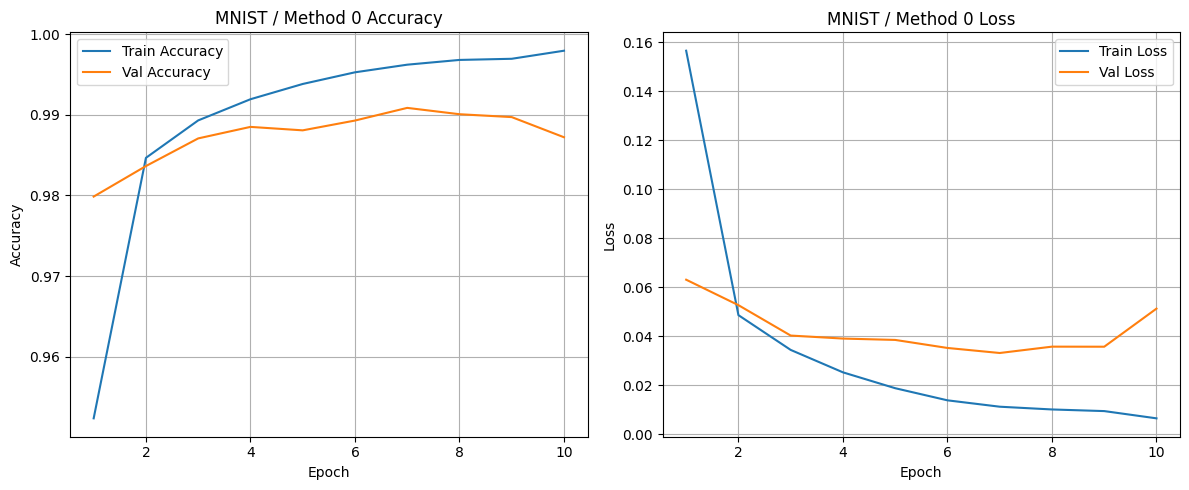


MNIST - Method 1
Epoch 1/10
875/875 - 5s - 5ms/step - accuracy: 0.9279 - loss: 0.2325 - val_accuracy: 0.9784 - val_loss: 0.0717
Epoch 2/10
875/875 - 4s - 5ms/step - accuracy: 0.9759 - loss: 0.0784 - val_accuracy: 0.9815 - val_loss: 0.0576
Epoch 3/10
875/875 - 4s - 5ms/step - accuracy: 0.9817 - loss: 0.0589 - val_accuracy: 0.9857 - val_loss: 0.0456
Epoch 4/10
875/875 - 4s - 5ms/step - accuracy: 0.9847 - loss: 0.0498 - val_accuracy: 0.9854 - val_loss: 0.0492
Epoch 5/10
875/875 - 4s - 5ms/step - accuracy: 0.9870 - loss: 0.0416 - val_accuracy: 0.9880 - val_loss: 0.0397
Epoch 6/10
875/875 - 4s - 5ms/step - accuracy: 0.9878 - loss: 0.0369 - val_accuracy: 0.9886 - val_loss: 0.0366
Epoch 7/10
875/875 - 5s - 5ms/step - accuracy: 0.9893 - loss: 0.0338 - val_accuracy: 0.9899 - val_loss: 0.0358
Epoch 8/10
875/875 - 4s - 5ms/step - accuracy: 0.9903 - loss: 0.0293 - val_accuracy: 0.9899 - val_loss: 0.0326
Epoch 9/10
875/875 - 4s - 5ms/step - accuracy: 0.9918 - loss: 0.0270 - val_accuracy: 0.9891 - 

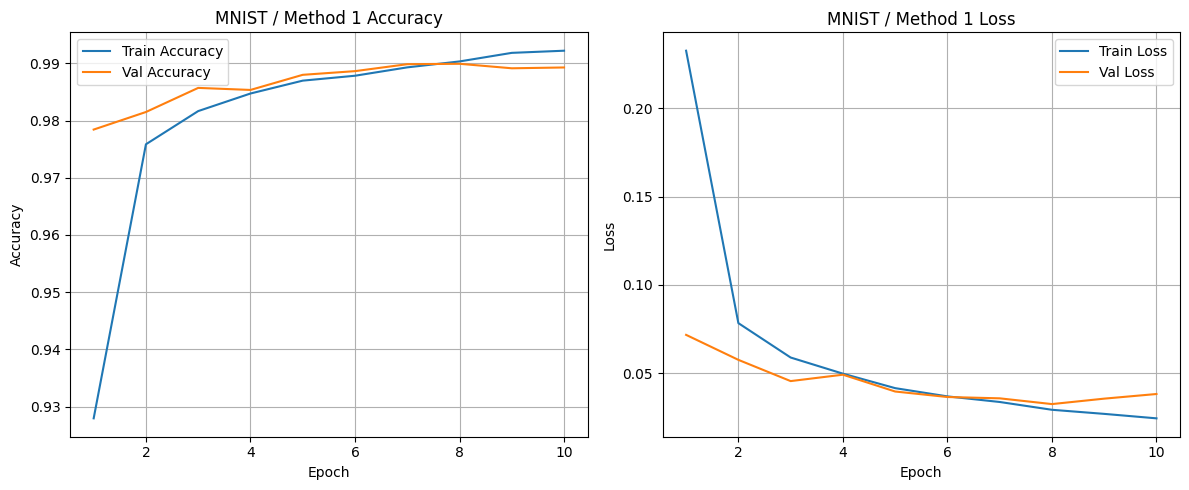


MNIST - Method 2
Epoch 1/10
875/875 - 5s - 6ms/step - accuracy: 0.9239 - loss: 0.2508 - val_accuracy: 0.9792 - val_loss: 0.0623
Epoch 2/10
875/875 - 4s - 5ms/step - accuracy: 0.9755 - loss: 0.0811 - val_accuracy: 0.9850 - val_loss: 0.0435
Epoch 3/10
875/875 - 4s - 5ms/step - accuracy: 0.9810 - loss: 0.0609 - val_accuracy: 0.9859 - val_loss: 0.0439
Epoch 4/10
875/875 - 4s - 5ms/step - accuracy: 0.9850 - loss: 0.0486 - val_accuracy: 0.9898 - val_loss: 0.0304
Epoch 5/10
875/875 - 4s - 5ms/step - accuracy: 0.9871 - loss: 0.0420 - val_accuracy: 0.9876 - val_loss: 0.0422
Epoch 6/10
875/875 - 4s - 5ms/step - accuracy: 0.9882 - loss: 0.0369 - val_accuracy: 0.9914 - val_loss: 0.0259
Epoch 7/10
875/875 - 4s - 5ms/step - accuracy: 0.9892 - loss: 0.0339 - val_accuracy: 0.9909 - val_loss: 0.0287
Epoch 8/10
875/875 - 4s - 5ms/step - accuracy: 0.9904 - loss: 0.0317 - val_accuracy: 0.9911 - val_loss: 0.0269
Epoch 9/10
875/875 - 4s - 5ms/step - accuracy: 0.9914 - loss: 0.0280 - val_accuracy: 0.9916 - 

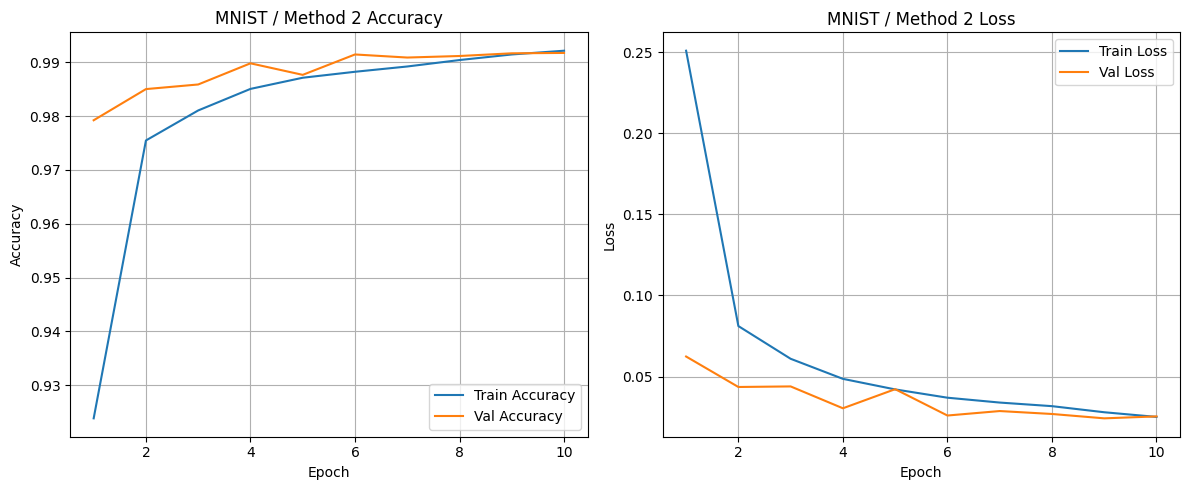


MNIST - Method 3
Epoch 1/10
875/875 - 5s - 6ms/step - accuracy: 0.9465 - loss: 0.1789 - val_accuracy: 0.9776 - val_loss: 0.0720
Epoch 2/10
875/875 - 4s - 5ms/step - accuracy: 0.9831 - loss: 0.0543 - val_accuracy: 0.9853 - val_loss: 0.0449
Epoch 3/10
875/875 - 4s - 5ms/step - accuracy: 0.9879 - loss: 0.0389 - val_accuracy: 0.9874 - val_loss: 0.0424
Epoch 4/10
875/875 - 4s - 5ms/step - accuracy: 0.9908 - loss: 0.0301 - val_accuracy: 0.9894 - val_loss: 0.0354
Epoch 5/10
875/875 - 4s - 5ms/step - accuracy: 0.9920 - loss: 0.0242 - val_accuracy: 0.9900 - val_loss: 0.0359
Epoch 6/10
875/875 - 4s - 5ms/step - accuracy: 0.9936 - loss: 0.0201 - val_accuracy: 0.9889 - val_loss: 0.0348
Epoch 7/10
875/875 - 4s - 4ms/step - accuracy: 0.9951 - loss: 0.0158 - val_accuracy: 0.9906 - val_loss: 0.0316
Epoch 8/10
875/875 - 4s - 5ms/step - accuracy: 0.9959 - loss: 0.0126 - val_accuracy: 0.9906 - val_loss: 0.0288
Epoch 9/10
875/875 - 4s - 4ms/step - accuracy: 0.9958 - loss: 0.0125 - val_accuracy: 0.9882 - 

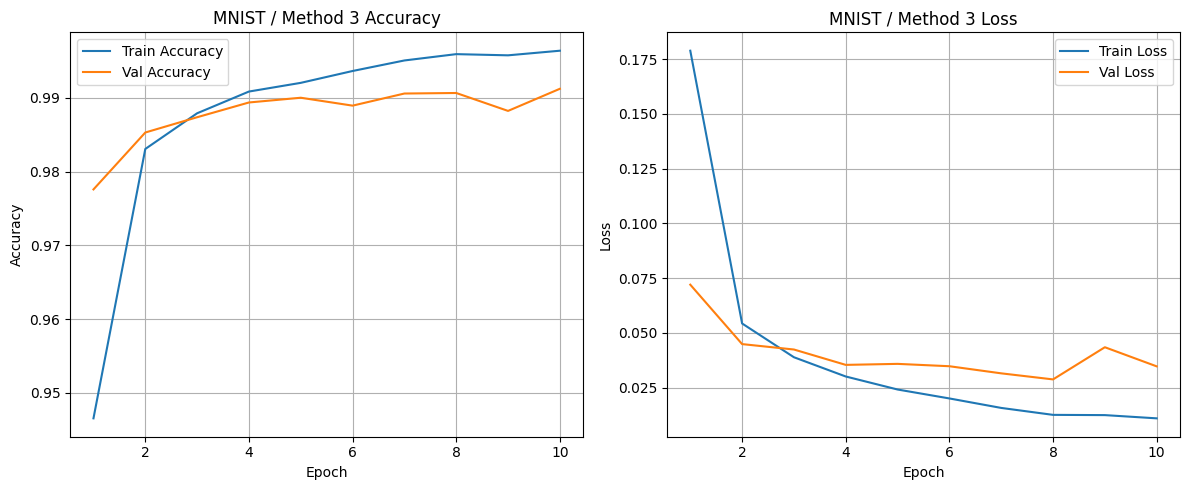


MNIST - Method 4
Epoch 1/10
875/875 - 5s - 5ms/step - accuracy: 0.8852 - loss: 0.3664 - val_accuracy: 0.9726 - val_loss: 0.0928
Epoch 2/10
875/875 - 4s - 5ms/step - accuracy: 0.9579 - loss: 0.1361 - val_accuracy: 0.9798 - val_loss: 0.0619
Epoch 3/10
875/875 - 4s - 5ms/step - accuracy: 0.9690 - loss: 0.0992 - val_accuracy: 0.9839 - val_loss: 0.0527
Epoch 4/10
875/875 - 4s - 5ms/step - accuracy: 0.9746 - loss: 0.0839 - val_accuracy: 0.9819 - val_loss: 0.0594
Epoch 5/10
875/875 - 4s - 5ms/step - accuracy: 0.9773 - loss: 0.0703 - val_accuracy: 0.9839 - val_loss: 0.0558
Epoch 6/10
875/875 - 4s - 5ms/step - accuracy: 0.9808 - loss: 0.0632 - val_accuracy: 0.9866 - val_loss: 0.0456
Epoch 7/10
875/875 - 4s - 5ms/step - accuracy: 0.9825 - loss: 0.0564 - val_accuracy: 0.9869 - val_loss: 0.0459
Epoch 8/10
875/875 - 4s - 5ms/step - accuracy: 0.9830 - loss: 0.0545 - val_accuracy: 0.9840 - val_loss: 0.0587
Epoch 9/10
875/875 - 4s - 5ms/step - accuracy: 0.9848 - loss: 0.0487 - val_accuracy: 0.9887 - 

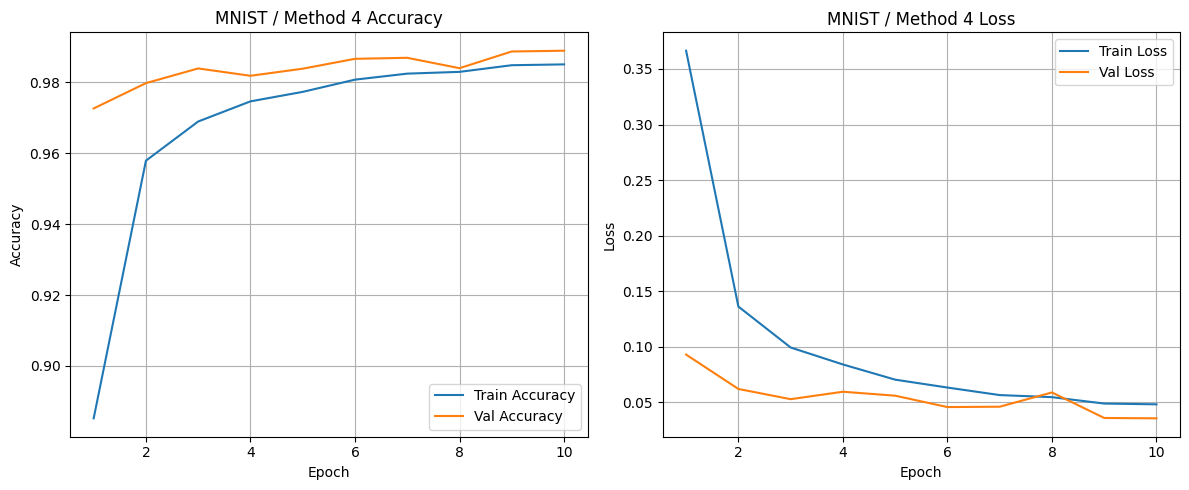


Final accuracy summary (MNIST):
Method 0: train_acc=0.9979, val_acc=0.9872
Method 1: train_acc=0.9922, val_acc=0.9893
Method 2: train_acc=0.9921, val_acc=0.9917
Method 3: train_acc=0.9964, val_acc=0.9912
Method 4: train_acc=0.9851, val_acc=0.9889


In [3]:
from keras.datasets import mnist

# EN: Load MNIST and merge train/test.
# CN: 加载 MNIST 并合并原始 train/test（你们清洗前就是这样做的）
(X0, y0), (X1, y1) = mnist.load_data()
X = np.concatenate([X0, X1], axis=0)
y = np.concatenate([y0, y1], axis=0)

# EN: Cleaning = MinMaxScaling to [0,1] (single normalization).
# CN: 清洗=MinMaxScaling 到 [0,1]（只做一次归一化）
X = X.astype("float32")
X = (X - X.min()) / (X.max() - X.min() + 1e-8)

# EN: Add channel dim -> (N,28,28,1).
# CN: 增加通道维度以适配 CNN
X = X[..., None]

# EN: Split after cleaning.
# CN: 清洗后再划分训练/验证（保证一致性）
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=SEED, shuffle=True
)

input_shape = (28, 28, 1)
num_classes = 10
is_rgb = False

results = {}

for method_id in range(5):
    print("\n==============================")
    print(f"MNIST - Method {method_id}")
    print("==============================")

    history, train_acc, val_acc = run_one_method(
        X_train, y_train, X_val, y_val,
        input_shape=input_shape, num_classes=num_classes,
        method_id=method_id, is_rgb=is_rgb
    )
    results[method_id] = (train_acc, val_acc)
    plot_acc_loss(history, title_prefix=f"MNIST / Method {method_id}")

print("\nFinal accuracy summary (MNIST):")
for k, (ta, va) in results.items():
    print(f"Method {k}: train_acc={ta:.4f}, val_acc={va:.4f}")

## Conclusion for MNIST (TensorFlow Data Augmentation) 